# AprilTag 도킹 — 블로그 코드 그대로, 카메라 없이

[joonhyung-lee 블로그](https://joonhyung-lee.github.io/blog/2023/apriltag-pose-estimation/)의
코드를 **그대로 가져다 쓰고**, RealSense로 프레임을 받는 부분만 합성 영상으로 바꿉니다.

| 표시 | 뜻 |
|---|---|
| `[블로그 원문]` | 블로그 코드 그대로. 카메라를 사면 이 셀들은 손 안 댑니다. |
| `[추가]` | 카메라 대체(합성 프레임) + 도킹 과제용 코드 |

**설정**: 태그는 탑재부 **입구 상단**에 4개, 크기는 전부 **한 변 25 cm** 로 통일.
지게차는 **3.5~4 m 앞, 여러 각도**에서 출발합니다.

In [1]:
# 블로그 의존 패키지: apriltag, pyrealsense2, opencv-python, numpy, matplotlib
import sys, subprocess
for pkg, imp in [("opencv-contrib-python", "cv2"), ("matplotlib", "matplotlib")]:
    try: __import__(imp)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import cv2
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
RNG = np.random.default_rng(7)

# --- apriltag 패키지 확보 -------------------------------------------------
# 블로그가 쓴 `apriltag`(Swatbotics) 패키지는 최신 setuptools에서 빌드가 자주 깨집니다.
# 설치돼 있으면 그대로 쓰고, 없으면 pupil-apriltags 위에 **같은 API**를 얹습니다.
# 어느 쪽이든 아래 블로그 코드는 한 글자도 바뀌지 않습니다.
try:
    import apriltag
    BACKEND = "apriltag (블로그 원본)"
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pupil-apriltags"])
    from pupil_apriltags import Detector as _PupilDetector

    class _Shim:
        """apriltag.Detector 와 동일한 API (detect / detection_pose)."""
        def __init__(self, options=None, families="tag36h11", **kw):
            self._d = _PupilDetector(families=families, nthreads=4)

        def detect(self, img, return_image=False):
            res = self._d.detect(img)
            return (res, np.zeros_like(img)) if return_image else res

        def detection_pose(self, detection, camera_params, tag_size=1.0, z_sign=1):
            fx, fy, cx, cy = camera_params
            K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], float)
            s = tag_size / 2.0
            obj = np.array([[-s, s, 0], [s, s, 0], [s, -s, 0], [-s, -s, 0]], np.float64)
            img_pts = np.array(detection.corners, np.float64)
            ok, rvec, tvec = cv2.solvePnP(obj, img_pts, K, None,
                                          flags=cv2.SOLVEPNP_IPPE_SQUARE)
            proj, _ = cv2.projectPoints(obj, rvec, tvec, K, None)
            e0 = float(np.sum((proj.reshape(-1, 2) - img_pts) ** 2))
            rvec, tvec = cv2.solvePnPRefineVVS(obj, img_pts, K, None, rvec, tvec)
            proj, _ = cv2.projectPoints(obj, rvec, tvec, K, None)
            e1 = float(np.sum((proj.reshape(-1, 2) - img_pts) ** 2))
            pose = np.eye(4)
            pose[:3, :3] = cv2.Rodrigues(rvec)[0]
            pose[:3, 3] = tvec.ravel()
            return pose, e0, e1

    class apriltag:                      # noqa: N801  (블로그 코드가 apriltag.Detector 를 부름)
        Detector = _Shim
    BACKEND = "pupil-apriltags (API 호환 shim)"

print("OpenCV", cv2.__version__, "| 백엔드:", BACKEND)

OpenCV 4.13.0 | 백엔드: pupil-apriltags (API 호환 shim)


## 1. `[블로그 원문]` RealSense 파이프라인 & intrinsic 추출

카메라가 없으니 실행은 안 하고 그대로 보관합니다.
바로 아래에서 **똑같은 변수 이름**(`cam_params_rgb`, `cam_matrix_rgb`)을 가상값으로 채웁니다.
카메라를 사면 주석만 풀면 됩니다.

In [2]:
# ─────────────── 블로그 원문 (카메라 있을 때) ───────────────
# import pyrealsense2 as rs
#
# pipeline = rs.pipeline()
# config = rs.config()
# config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
# config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
#
# profile = pipeline.start(config)
# stream_depth = profile.get_stream(rs.stream.depth)
#
# intrinsic_matrix_depth = stream_depth.as_video_stream_profile().get_intrinsics()
# intrinsic_matrix_rgb = profile.get_stream(rs.stream.color).as_video_stream_profile().get_intrinsics()
#
# cam_params_depth = [intrinsic_matrix_depth.fx, intrinsic_matrix_depth.fy,
#                     intrinsic_matrix_depth.ppx, intrinsic_matrix_depth.ppy]
# cam_params_rgb = [intrinsic_matrix_rgb.fx, intrinsic_matrix_rgb.fy,
#                   intrinsic_matrix_rgb.ppx, intrinsic_matrix_rgb.ppy]
#
# cam_matrix_rgb = np.array([[intrinsic_matrix_rgb.fx, 0, intrinsic_matrix_rgb.ppx],
#                            [0, intrinsic_matrix_rgb.fy, intrinsic_matrix_rgb.ppy],
#                            [0, 0, 1]])
# ────────────────────────────────────────────────────────────

# [추가] 가상 카메라 — 위 블로그 코드가 만들어낼 값과 똑같은 형태
W, H = 1280, 720                     # 블로그는 640x480. 도킹 거리가 기니 720p 로 올렸습니다.
FX = FY = 900.0
CX, CY = W / 2.0, H / 2.0

cam_params_rgb = [FX, FY, CX, CY]
cam_matrix_rgb = np.array([[FX, 0, CX],
                           [0, FY, CY],
                           [0,  0,  1]])
DIST = np.array([-0.28, 0.09, 0.001, -0.001, 0.0])    # 광각 렌즈 배럴 왜곡

print("cam_params_rgb =", cam_params_rgb)
print(f"수평 FOV {2*np.degrees(np.arctan(CX/FX)):.1f}°")

cam_params_rgb = [900.0, 900.0, 640.0, 360.0]
수평 FOV 70.8°


## 2. `[블로그 원문]` `meters2xyz()` — depth → 포인트클라우드

태그 자세 추정에는 안 쓰이지만, 블로그 코드라 그대로 둡니다.
나중에 D435i 를 사서 depth 로 거리를 교차검증할 때 이 함수가 필요합니다.

In [3]:
def meters2xyz(depth_img, camera_info):
    """Convert depth image to point cloud coordinates"""
    fx = camera_info.fx
    cx = camera_info.ppx
    fy = camera_info.fy
    cy = camera_info.ppy

    height = camera_info.height
    width = camera_info.width

    indices = np.indices((height, width), dtype=np.float32).transpose(1, 2, 0)

    z_e = depth_img
    x_e = (indices[..., 1] - cx) * z_e / fx
    y_e = (indices[..., 0] - cy) * z_e / fy

    xyz_img = np.stack([-y_e * 0.001, -x_e * 0.001, z_e * 0.001], axis=-1)
    return xyz_img

## 3. `[추가]` 좌표계 + 탑재부 태그 배치

```
dock (탑재부)  x = 지게차 진입 방향, y = 좌, z = 상,  원점 = 목표 주차 지점
base (차체)    x = 전진, y = 좌, z = 상
cam  (카메라)  x = 우, y = 하, z = 광축         ← 비전 관례
```

### 태그 크기를 25 cm 로 정한 이유

검출이 안정적이려면 태그 한 변이 화면에서 **최소 40 px, 편하게는 60 px** 은 되어야 합니다.
`w_px = fx · s / z` 이므로 `fx=900`, 25 cm 태그면:

| 거리 | 화면상 크기 | |
|---|---|---|
| 3.0 m | 75 px | 아주 여유 |
| **3.8 m** | **59 px** | **← 출발 지점** |
| 5.0 m | 45 px | 경계 |
| 6.0 m | 38 px | 불안정 |

그래서 **출발은 3.5~4 m**. A3 한 장에 한 개씩 인쇄되는 크기이기도 합니다
(검은 사각형 25 cm + 흰 여백 3 cm = 31 cm).

### 배치 — 입구 상단, 그런데 일렬로 붙이면 안 됩니다

태그를 전부 같은 높이에 일렬로 붙이면 점들이 거의 한 직선 위에 놓여
**PnP 기하가 약해집니다.** 그래서 두 가지를 섞었습니다.

- 높이를 두 단으로 (상단 빔 2.05 m / 기둥 상부 1.80 m)
- **앞뒤로 25 cm 차이** — 문틀 앞면(x=0.95)과 안쪽 벽(x=1.20)에 나눠 부착

앞뒤 차이가 핵심입니다. 깊이 방향으로 점이 퍼지면 자세가 뒤집히는 flip ambiguity 가 사라집니다.

### 카메라를 위로 25° 틸트해야 하는 이유

태그가 **상단**에 있으니 정면만 보는 카메라는 다 왔을 때 태그를 놓칩니다. 계산해 보면:

- 목표 주차 지점에서 카메라(높이 1.2 m)가 태그(2.05 m)를 올려다보는 각도
  `atan(0.85 / 0.9) ≈ 43°`
- 720p·`fy=900` 의 **수직 반화각은 21.8°**
- 따라서 최소 `43 − 21.8 ≈ 21°` 틸트 필요 → 여유를 둬 **25°**

틸트를 15° 로 하면 마지막 60 cm 에서 태그가 전부 사라져 데드레커닝에 의존하게 됩니다
(실제로 그렇게 돌려보고 25° 로 올렸습니다). 대신 25° 면 카메라가 바닥 쪽을 거의 못 보므로,
**도킹 전용 카메라**로 쓰고 주행용 카메라는 따로 두는 편이 낫습니다.

In [4]:
TAG_SIZE = 0.25                                   # 전부 동일

# id: (x, y, z)  — 태그 중심, dock 좌표계
TAG_LAYOUT = {
    0: (0.95, -0.85, 1.80),   # 좌측 기둥 상부 (문틀 앞면)
    1: (1.20, -0.30, 2.05),   # 입구 상단 빔 좌
    2: (1.20,  0.30, 2.05),   # 입구 상단 빔 우
    3: (0.95,  0.85, 1.80),   # 우측 기둥 상부 (문틀 앞면)
}

def tag_corners_3d(x, cy, cz, size=TAG_SIZE):
    """검은 사각형 바깥 모서리 4점 (TL→TR→BR→BL, dock 좌표계)."""
    h = size / 2
    return np.array([[x, cy + h, cz + h],
                     [x, cy - h, cz + h],
                     [x, cy - h, cz - h],
                     [x, cy + h, cz - h]], float)

OBJ_PTS = {t: tag_corners_3d(*v) for t, v in TAG_LAYOUT.items()}

def rt_to_T(R, t):
    T = np.eye(4); T[:3, :3] = R; T[:3, 3] = np.asarray(t).ravel(); return T

def inv_T(T):
    R, t = T[:3, :3], T[:3, 3]
    o = np.eye(4); o[:3, :3] = R.T; o[:3, 3] = -R.T @ t; return o

def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], float)

def Ry(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]], float)

def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

# --- 카메라 장착 (0-5단계 외부 캘리브레이션에 해당) ---
CAM_TILT = np.deg2rad(25)      # 태그가 입구 "상단"에 있으므로 위로 25° 올려 답니다 (계산 근거는 위 설명)
CAM_MOUNT = [0.30, 0.0, 1.20]  # 차체 기준점 앞 30cm, 높이 1.2m

R_base_cam = Ry(-CAM_TILT) @ np.array([[0, 0, 1],
                                       [-1, 0, 0],
                                       [0, -1, 0]], float)
T_BASE_CAM = rt_to_T(R_base_cam, CAM_MOUNT)

def cam_T_from_base(x, y, th):
    """차체 자세 (x, y, θ) → T_cam_dock."""
    return inv_T(rt_to_T(Rz(th), [x, y, 0.0]) @ T_BASE_CAM)

for t, (x, y, z) in TAG_LAYOUT.items():
    print(f"  id={t}  x={x:.2f}  y={y:+.2f}  z={z:.2f}  ({TAG_SIZE*100:.0f}cm)")
print(f"\n카메라: 높이 {CAM_MOUNT[2]} m, 위로 {np.degrees(CAM_TILT):.0f}° 틸트")

  id=0  x=0.95  y=-0.85  z=1.80  (25cm)
  id=1  x=1.20  y=-0.30  z=2.05  (25cm)
  id=2  x=1.20  y=+0.30  z=2.05  (25cm)
  id=3  x=0.95  y=+0.85  z=1.80  (25cm)

카메라: 높이 1.2 m, 위로 25° 틸트


## 4. `[추가]` 합성 프레임 생성기 — RealSense 대체

정답 자세를 우리가 정해놓고, 그 자세에서 보일 영상을 그립니다.
**정답을 알고 있으니 추정 결과를 mm 단위로 채점할 수 있습니다.** 실물 카메라로는 못 하는 일입니다.

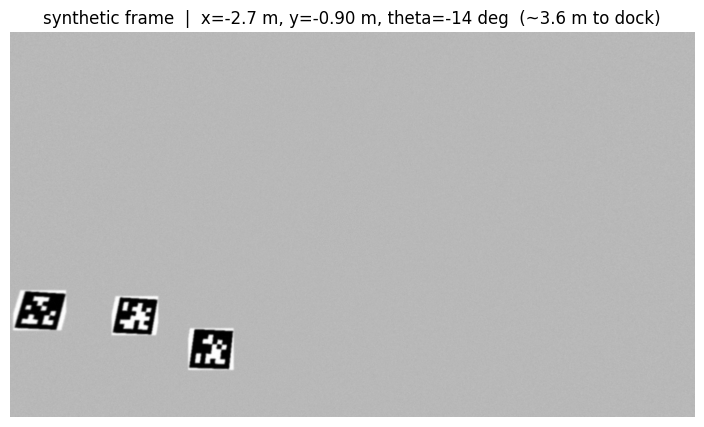

In [5]:
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_APRILTAG_36h11)

def make_tag_image(tid, cell=50):
    """8셀 검은 사각형 + 1셀 흰 여백. 확대는 반드시 NEAREST (보간하면 검출 실패)."""
    black = cv2.aruco.generateImageMarker(ARUCO_DICT, tid, 8 * cell)
    img = np.full((10 * cell, 10 * cell), 255, np.uint8)
    img[cell:9 * cell, cell:9 * cell] = black
    return img, cell, 8 * cell

TAG_IMGS = {t: make_tag_image(t) for t in TAG_LAYOUT}

_uu, _vv = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
_ideal = cv2.undistortPoints(np.stack([_uu, _vv], -1).reshape(-1, 1, 2),
                             cam_matrix_rgb, DIST, P=cam_matrix_rgb).reshape(H, W, 2)
DMAP1, DMAP2 = cv2.convertMaps(_ideal[..., 0].copy(), _ideal[..., 1].copy(), cv2.CV_16SC2)

def get_frame(x, y, th, blur=1.0, noise=3.0, bg=185):
    """RealSense 의 wait_for_frames() 자리. 차체 자세 → 그레이 영상 한 장."""
    T = cam_T_from_base(x, y, th)
    R, t = T[:3, :3], T[:3, 3]
    rvec, _ = cv2.Rodrigues(R)
    canvas = np.full((H, W), bg, np.uint8)

    for tid, obj in OBJ_PTS.items():
        cam_pts = (R @ obj.T).T + t
        if np.any(cam_pts[:, 2] < 0.15):
            continue
        n_cam = R @ np.array([-1.0, 0, 0])                       # 태그 법선
        ctr = cam_pts.mean(0)
        if n_cam @ (ctr / np.linalg.norm(ctr)) > -0.25:          # 뒷면 / 너무 비스듬
            continue
        ip, _ = cv2.projectPoints(obj, rvec, t, cam_matrix_rgb, None)
        ip = ip.reshape(-1, 2).astype(np.float32)
        if np.any(np.abs(ip) > 6000):
            continue
        # 태그가 차지하는 사각형만 워핑 (전체 화면을 돌리면 수십 배 느립니다)
        x0, y0 = np.floor(ip.min(0)).astype(int) - 1
        x1, y1 = np.ceil(ip.max(0)).astype(int) + 1
        x0, y0 = max(x0, 0), max(y0, 0)
        x1, y1 = min(x1, W), min(y1, H)
        if x1 - x0 < 3 or y1 - y0 < 3:
            continue
        tag_img, pad, n = TAG_IMGS[tid]
        src = np.float32([[pad, pad], [pad + n, pad], [pad + n, pad + n], [pad, pad + n]])
        Hm = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]], float) @ cv2.getPerspectiveTransform(src, ip)
        sz = (int(x1 - x0), int(y1 - y0))
        warp = cv2.warpPerspective(tag_img, Hm, sz, borderValue=0)
        mask = cv2.warpPerspective(np.full(tag_img.shape, 255, np.uint8), Hm, sz, borderValue=0)
        sub = canvas[y0:y1, x0:x1]
        sub[mask > 128] = warp[mask > 128]

    canvas = cv2.remap(canvas, DMAP1, DMAP2, cv2.INTER_LINEAR, borderValue=bg)   # 렌즈 왜곡
    if blur > 0:
        canvas = cv2.GaussianBlur(canvas, (0, 0), blur)
    if noise > 0:
        canvas = np.clip(canvas + RNG.normal(0, noise, canvas.shape), 0, 255).astype(np.uint8)
    return canvas

# 왜곡 보정 맵 (블로그엔 없지만 실전 필수)
UMAP1, UMAP2 = cv2.initUndistortRectifyMap(cam_matrix_rgb, DIST, None,
                                           cam_matrix_rgb, (W, H), cv2.CV_16SC2)
def undistort(img):
    return cv2.remap(img, UMAP1, UMAP2, cv2.INTER_LINEAR)

START = (-2.7, -0.9, np.deg2rad(-14))
img_gray = undistort(get_frame(*START))
plt.figure(figsize=(9, 5)); plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.title("synthetic frame  |  x=-2.7 m, y=-0.90 m, theta=-14 deg  (~3.6 m to dock)")
plt.axis("off"); plt.show()

## 5. `[블로그 원문]` 태그 검출

그레이스케일로 넘기는 이유: 검출기가 내부에서 밝기 채널만 쓰기 때문입니다.

In [6]:
detector = apriltag.Detector()
tag_size = TAG_SIZE

results, dimg = detector.detect(img_gray, return_image=True)

print(f"검출된 태그 {len(results)}개")
for r in results:
    print(f"  id={r.tag_id}  hamming={r.hamming}  margin={r.decision_margin:6.1f}  "
          f"center=({r.center[0]:6.1f}, {r.center[1]:6.1f})")

검출된 태그 3개
  id=0  hamming=0  margin= 101.9  center=( 376.7,  592.7)
  id=1  hamming=0  margin= 106.6  center=( 234.8,  530.7)
  id=2  hamming=0  margin= 108.2  center=(  57.3,  520.6)


## 6. `[블로그 원문]` 자세 추정 — `detection_pose()`

`camera_params` 와 `tag_size` 를 **여기서 넣어야** 픽셀이 미터가 됩니다.
반환값 `pose` 는 4×4 `T_cam_tag`, `e0`/`e1` 은 최적화 전/후 재투영 오차입니다.

In [7]:
poses = {}
for r in results:
    pose, e0, e1 = detector.detection_pose(
        detection=r,
        camera_params=cam_params_rgb,   # [fx, fy, cx, cy]
        tag_size=tag_size)
    poses[r.tag_id] = pose
    R_t, t_t = pose[:3, :3], pose[:3, 3]
    print(f"id={r.tag_id}  t(cam)= {t_t.round(3)}  거리 {np.linalg.norm(t_t):.3f} m   e0={e0:.3f} → e1={e1:.3f}")

id=0  t(cam)= [-0.931  0.823  3.182]  거리 3.416 m   e0=0.032 → e1=0.031
id=1  t(cam)= [-1.524  0.642  3.386]  거리 3.769 m   e0=0.000 → e1=0.000
id=2  t(cam)= [-2.111  0.582  3.261]  거리 3.928 m   e0=0.053 → e1=0.052


## 7. `[블로그 원문]` `_draw_cube()` — 결과 검증

태그 좌표계에서 정육면체를 정의하고, 방금 구한 `pose` 로 이미지에 되투영합니다.
큐브가 태그에 딱 붙어 보이면 자세가 맞는 겁니다.

In [8]:
def _draw_cube(overlay, camera_params, tag_size, pose, z_sign=1):
    """Draw 3D bounding cube projected onto image"""
    opoints = np.array([
        -1, -1, 0,  -1, -1, -2 * z_sign,
         1, -1, 0,   1, -1, -2 * z_sign,
         1,  1, 0,   1,  1, -2 * z_sign,
        -1,  1, 0,  -1,  1, -2 * z_sign,
    ]).reshape(-1, 1, 3) * 0.5 * tag_size

    edges = np.array([0, 1, 1, 3, 3, 2, 2, 0, 0, 4, 1, 5, 2, 6, 3, 7,
                      4, 5, 5, 7, 7, 6, 6, 4]).reshape(-1, 2)

    fx, fy, cx, cy = camera_params
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])

    rvec, _ = cv2.Rodrigues(pose[:3, :3])
    tvec = pose[:3, 3]

    ipoints, _ = cv2.projectPoints(opoints, rvec, tvec, K, np.zeros(5))
    ipoints = np.round(ipoints).astype(int).reshape(-1, 2)

    for i, j in edges:
        cv2.line(overlay, tuple(ipoints[i]), tuple(ipoints[j]), (0, 255, 0), 2, cv2.LINE_AA)
    return overlay

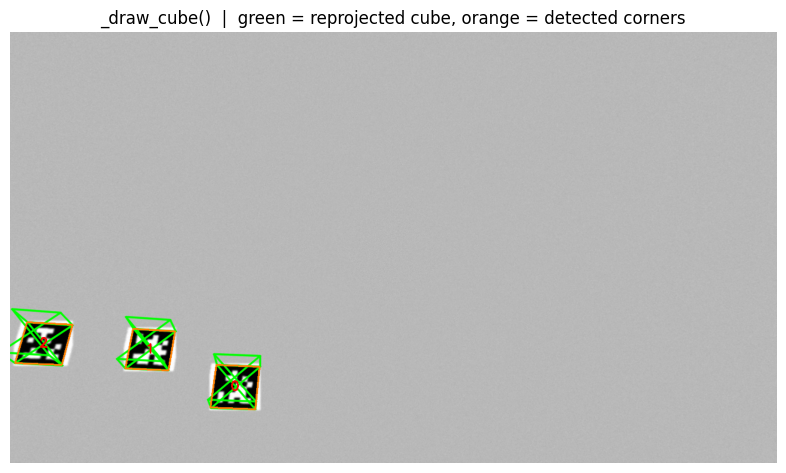

In [9]:
overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
for r in results:
    _draw_cube(overlay, cam_params_rgb, tag_size, poses[r.tag_id])
    c = np.int32(r.corners)
    cv2.polylines(overlay, [c], True, (0, 128, 255), 2)
    cv2.putText(overlay, str(r.tag_id), (int(r.center[0]) - 8, int(r.center[1]) + 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

plt.figure(figsize=(10, 5.6)); plt.imshow(overlay[..., ::-1])
plt.title("_draw_cube()  |  green = reprojected cube, orange = detected corners")
plt.axis("off"); plt.show()

## 8. `[추가]` 좌표 변환 — 블로그가 이론만 설명한 부분

블로그는 여기서 MuJoCo 월드 프레임으로 넘어가지만, 우리는 **탑재부 기준 지게차 자세**가 필요합니다.

1. 검출된 태그 코너를 **전부** 모아 한 번에 `solvePnP` → `T_cam_dock`
2. 뒤집어서 `T_dock_base` → `(횡이탈 y, 진입 거리 x, 진입각 θ)`

In [10]:
# pupil-apriltags/apriltag 의 corners 순서 → 우리 3D 표(TL,TR,BR,BL) 순서
CORNER_MAP = [1, 0, 3, 2]

def estimate_dock_pose(results):
    """검출 결과 전체 → (x, y, θ, 재투영RMS, 사용한 태그들). 실패 시 None."""
    ids = [r.tag_id for r in results if r.tag_id in OBJ_PTS]
    if not ids:
        return None
    obj = np.vstack([OBJ_PTS[r.tag_id] for r in results if r.tag_id in OBJ_PTS])
    img = np.vstack([np.array(r.corners, np.float64)[CORNER_MAP]
                     for r in results if r.tag_id in OBJ_PTS])

    flags = cv2.SOLVEPNP_IPPE_SQUARE if len(ids) == 1 else cv2.SOLVEPNP_SQPNP
    ok, rvec, tvec = cv2.solvePnP(obj, img, cam_matrix_rgb, None, flags=flags)
    if not ok:
        return None
    rvec, tvec = cv2.solvePnPRefineVVS(obj, img, cam_matrix_rgb, None, rvec, tvec)

    proj, _ = cv2.projectPoints(obj, rvec, tvec, cam_matrix_rgb, None)
    rms = float(np.sqrt(np.mean(np.sum((proj.reshape(-1, 2) - img) ** 2, 1))))

    T_cam_dock = rt_to_T(cv2.Rodrigues(rvec)[0], tvec)
    T_dock_base = inv_T(T_cam_dock) @ inv_T(T_BASE_CAM)
    return (T_dock_base[0, 3], T_dock_base[1, 3],
            np.arctan2(T_dock_base[1, 0], T_dock_base[0, 0]), rms, sorted(ids))

def run_pipeline(x, y, th, **kw):
    """한 프레임 전체 파이프라인."""
    return estimate_dock_pose(detector.detect(undistort(get_frame(x, y, th, **kw))))

e = run_pipeline(*START)
print(f"정답  x={START[0]:+.3f} m  y={START[1]:+.3f} m  θ={np.degrees(START[2]):+.2f}°")
print(f"추정  x={e[0]:+.3f} m  y={e[1]:+.3f} m  θ={np.degrees(e[2]):+.2f}°")
print(f"오차  Δx={e[0]-START[0]*1:+.3f} m  Δy={e[1]-START[1]:+.3f} m  "
      f"Δθ={np.degrees(wrap(e[2]-START[2])):+.2f}°")
print(f"재투영 RMS {e[3]:.2f} px · 사용 태그 {e[4]}")

정답  x=-2.700 m  y=-0.900 m  θ=-14.00°
추정  x=-2.716 m  y=-0.884 m  θ=-14.19°
오차  Δx=-0.016 m  Δy=+0.016 m  Δθ=-0.19°
재투영 RMS 0.19 px · 사용 태그 [0, 1, 2]


## 9. `[추가]` 여러 각도에서 출발 — 커버리지 맵

**어느 위치·각도에서 출발해야 태그가 보이는가?** 태그를 몇 개 잡느냐로 색을 칠했습니다.
진입 시작 지점을 정할 때 이 그림이 근거가 됩니다.

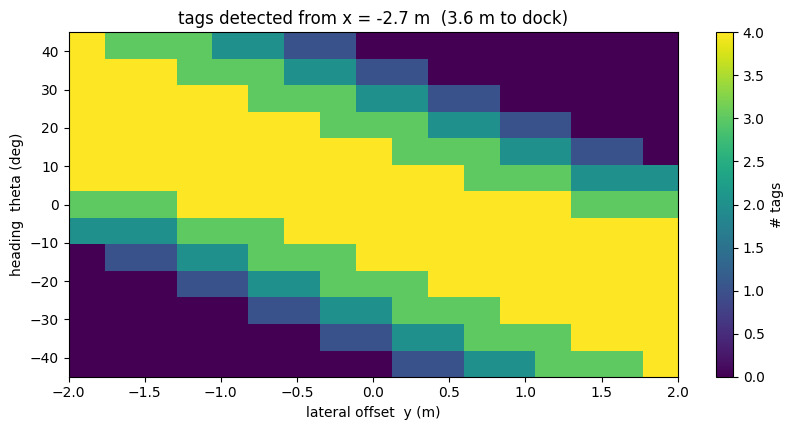

태그 2개 이상 잡히는 출발 자세 비율: 68%
안전한 진입각 범위: -45° ~ +45°
   θ=-45° 일 때 y = +0.8 ~ +2.0 m
   θ=-15° 일 때 y = -1.2 ~ +2.0 m
   θ=+15° 일 때 y = -2.0 ~ +1.2 m
   θ=+45° 일 때 y = -2.0 ~ -0.8 m


In [11]:
ys = np.arange(-2.0, 2.01, 0.25)
ths = np.arange(-45, 45.1, 7.5)
grid = np.zeros((len(ths), len(ys)))
for i, th in enumerate(ths):
    for j, y in enumerate(ys):
        res = detector.detect(undistort(get_frame(-2.7, y, np.deg2rad(th), noise=2.0)))
        grid[i, j] = sum(1 for r in res if r.tag_id in OBJ_PTS)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=4,
               extent=[ys[0], ys[-1], ths[0], ths[-1]])
ax.set_xlabel("lateral offset  y (m)"); ax.set_ylabel("heading  theta (deg)")
ax.set_title("tags detected from x = -2.7 m  (3.6 m to dock)")
plt.colorbar(im, ax=ax, label="# tags"); plt.tight_layout(); plt.show()

ok2 = (grid >= 2).mean() * 100
print(f"태그 2개 이상 잡히는 출발 자세 비율: {ok2:.0f}%")
rows = [(ths[i], ys[grid[i] >= 2]) for i in range(len(ths))]
good = [r for r in rows if len(r[1])]
print(f"안전한 진입각 범위: {good[0][0]:+.0f}° ~ {good[-1][0]:+.0f}°")
for th_, yy in good[::4]:
    print(f"   θ={th_:+3.0f}° 일 때 y = {yy.min():+.1f} ~ {yy.max():+.1f} m")

## 10. `[추가]` 블로그 방식(태그 1개) vs 태그 전부

블로그의 `detection_pose()` 는 **태그 하나씩** 자세를 냅니다. 정면 근접에서 이게 왜 위험한지 봅니다.

In [12]:
for mode in ["태그 1개 (블로그 방식)", "태그 전부 (멀티 PnP)"]:
    errs = []
    for _ in range(20):
        y0, t0 = RNG.uniform(-0.2, 0.2), np.deg2rad(RNG.uniform(-4, 4))
        res = detector.detect(undistort(get_frame(-1.8, y0, t0, noise=4.0, blur=1.2)))
        res = [r for r in res if r.tag_id in OBJ_PTS]
        if not res:
            continue
        if mode.startswith("태그 1개"):
            res = [res[0]]
        out = estimate_dock_pose(res)
        if out:
            errs.append(abs(np.degrees(wrap(out[2] - t0))))
    print(f"  {mode:22s} 진입각 오차 평균 {np.mean(errs):6.2f}° / 최대 {np.max(errs):6.2f}°")

  태그 1개 (블로그 방식)         진입각 오차 평균   4.24° / 최대   7.68°


  태그 전부 (멀티 PnP)         진입각 오차 평균   0.07° / 최대   0.19°


## 11. `[추가]` 여러 각도에서 폐루프 도킹

매 스텝 **영상을 새로 그려서 → 블로그 검출 → 자세 추정 → 제어**까지 한 바퀴 돕니다.
제어기는 정답을 모르고 추정값만 봅니다. 10% 확률로 프레임을 일부러 버려서
태그를 못 보는 구간(데드레커닝)도 만들고, 오래 못 보면 **안전 정지**합니다.

In [13]:
DT = 0.1
def control(x, y, th):
    rho = np.hypot(x, y)
    if rho < 0.12:                                     # FINAL — 각도만 미세 정렬
        return np.clip(-0.6 * x, -0.2, 0.2), np.clip(-2.0 * th, -0.5, 0.5), rho
    a = wrap(np.arctan2(-y, -x) - th)
    b = wrap(-th - a)
    return np.clip(0.45 * rho, 0, 0.6), np.clip(1.3 * a - 0.35 * b, -0.8, 0.8), rho

# 출발 자세는 9번 커버리지 맵에서 "태그 2개 이상 보이는" 영역에서 골랐습니다.
# 왼쪽(y>0)에 있으면 오른쪽으로(θ<0) 틀어야 탑재부가 보입니다.
STARTS = [(-2.7, -1.20, np.deg2rad( 25)), (-2.7, -0.60, np.deg2rad( 10)),
          (-2.7,  0.00, np.deg2rad( -8)), (-2.7,  0.70, np.deg2rad(-20)),
          (-2.7,  1.30, np.deg2rad(-30))]

MAX_BLIND = 40          # 이만큼 연속으로 못 보면 안전 정지

tracks, finals = [], []
for s0 in STARTS:
    st = np.array(s0, float)
    est, v, w, blind, mx = None, 0.0, 0.0, 0, 0
    tr = []
    for _ in range(300):
        out = None if RNG.random() < 0.10 else run_pipeline(*st, noise=4.0, blur=1.2)

        # 게이트: 재투영 오차가 작고 **태그를 2개 이상** 썼을 때만 신뢰합니다.
        # 태그 1개짜리 해는 오차가 작아도 뒤집혀 있을 수 있습니다 (10번 셀 참고).
        if out and out[3] < 3.0 and len(out[4]) >= 2:
            est, blind = out[:3], 0
        elif est is not None:                          # 데드레커닝
            ex, ey, et = est
            est = (ex + v * np.cos(et) * DT, ey + v * np.sin(et) * DT, wrap(et + w * DT))
            blind += 1; mx = max(mx, blind)
        else:
            continue                                   # 아직 한 번도 못 봄 → 정지 대기

        if blind > MAX_BLIND:
            print("   ⚠ 태그 장시간 미검출 → 안전 정지"); break

        v, w, rho = control(*est)
        tr.append(st.copy())
        if rho < 0.015 and abs(est[2]) < np.deg2rad(0.8):
            break
        st[0] += v * np.cos(st[2]) * DT
        st[1] += v * np.sin(st[2]) * DT
        st[2] = wrap(st[2] + w * DT)
    tracks.append(np.array(tr)); finals.append(st.copy())
    print(f"출발 y={s0[1]:+.2f} θ={np.degrees(s0[2]):+5.1f}°  →  {len(tr)*DT:5.1f}초 · "
          f"최종 x={st[0]*1000:+6.1f}mm y={st[1]*1000:+6.1f}mm θ={np.degrees(st[2]):+5.2f}°  "
          f"(최대 연속 미검출 {mx}프레임)")

f = np.array(finals)
print(f"\n반복 정밀도  σx={f[:,0].std()*1000:.1f}mm  σy={f[:,1].std()*1000:.1f}mm  "
      f"σθ={np.degrees(f[:,2]).std():.2f}°")

출발 y=-1.20 θ=+25.0°  →   11.4초 · 최종 x= -19.9mm y=  -4.0mm θ=-0.00°  (최대 연속 미검출 2프레임)


출발 y=-0.60 θ=+10.0°  →   11.1초 · 최종 x= -19.8mm y=  -2.3mm θ=-0.00°  (최대 연속 미검출 5프레임)


출발 y=+0.00 θ= -8.0°  →   10.9초 · 최종 x= -21.8mm y=  -1.0mm θ=-0.01°  (최대 연속 미검출 3프레임)


출발 y=+0.70 θ=-20.0°  →   10.8초 · 최종 x= -23.3mm y=  +1.9mm θ=-0.02°  (최대 연속 미검출 1프레임)


출발 y=+1.30 θ=-30.0°  →   11.2초 · 최종 x= -23.1mm y=  +4.0mm θ=-0.02°  (최대 연속 미검출 2프레임)

반복 정밀도  σx=1.5mm  σy=2.9mm  σθ=0.01°


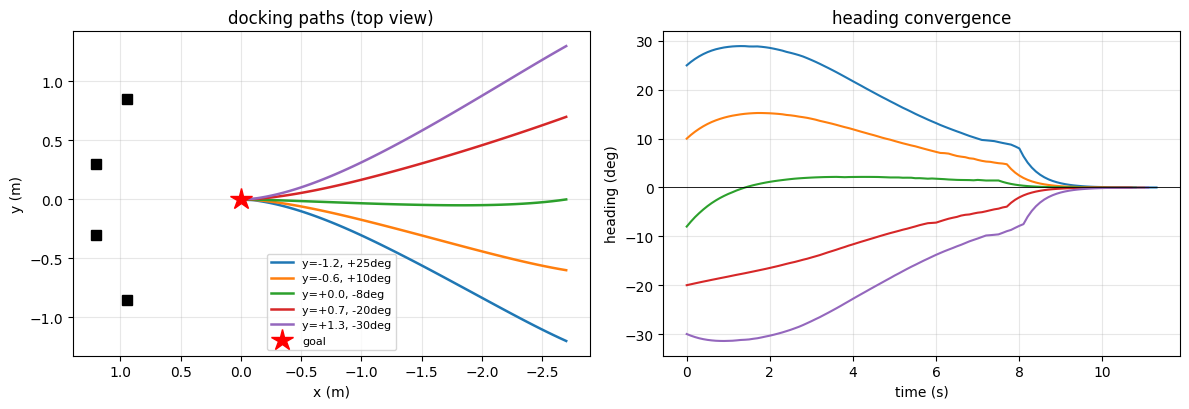

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for tr, s0 in zip(tracks, STARTS):
    ax[0].plot(tr[:, 0], tr[:, 1], lw=1.8, label=f"y={s0[1]:+.1f}, {np.degrees(s0[2]):+.0f}deg")
    ax[1].plot(np.arange(len(tr)) * DT, np.degrees(tr[:, 2]), lw=1.5)
for tid, (x, y, z) in TAG_LAYOUT.items():
    ax[0].plot(x, y, "ks", ms=7)
ax[0].plot(0, 0, "r*", ms=16, label="goal")
ax[0].set_xlabel("x (m)"); ax[0].set_ylabel("y (m)"); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8); ax[0].set_title("docking paths (top view)"); ax[0].invert_xaxis()
ax[1].axhline(0, color="k", lw=.6); ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("heading (deg)"); ax[1].grid(alpha=.3); ax[1].set_title("heading convergence")
plt.tight_layout(); plt.show()

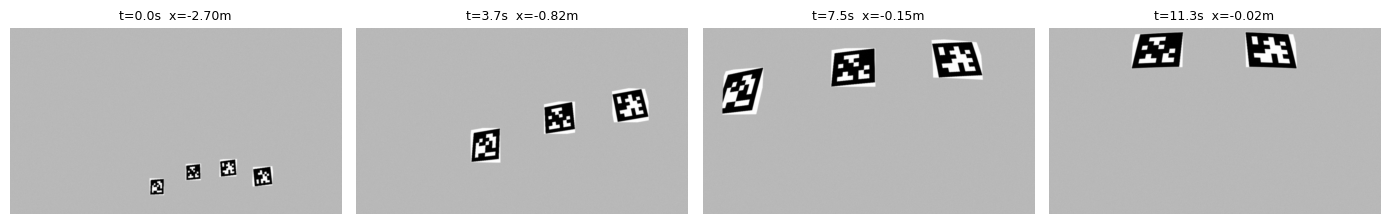

가까워질수록 태그가 화면 위쪽으로 올라옵니다. 25° 틸트 덕분에 마지막까지 시야에 남습니다.


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(14, 2.7))
tr = tracks[0]
for ax_, i in zip(axes, np.linspace(0, len(tr) - 1, 4).astype(int)):
    ax_.imshow(get_frame(*tr[i], noise=3.0), cmap="gray", vmin=0, vmax=255)
    ax_.set_title(f"t={i*DT:.1f}s  x={tr[i,0]:+.2f}m", fontsize=9); ax_.axis("off")
plt.tight_layout(); plt.show()
print("가까워질수록 태그가 화면 위쪽으로 올라옵니다. 25° 틸트 덕분에 마지막까지 시야에 남습니다.")

## 12. 실물 카메라를 사면 바꿀 곳

| 셀 | 지금 | 실물 |
|---|---|---|
| 1번 | 블로그 RealSense 코드가 **주석 처리** | 주석만 풀면 끝. `cam_params_rgb` 가 자동으로 채워집니다 |
| 3번 `TAG_LAYOUT` | 우리가 정한 값 | 입구에 실제로 붙인 뒤 **mm 단위 실측** |
| 3번 `T_BASE_CAM` | 우리가 정한 값 | 실측 또는 `cv2.calibrateHandEye()` |
| 4번 `get_frame()` | 합성 | `pipeline.wait_for_frames()` 로 교체 |
| 4번 `DIST` | 우리가 정한 값 | 체커보드 `cv2.calibrateCamera()` 결과 |

**5~11번 셀은 한 줄도 안 바뀝니다.** 블로그 코드(5·6·7번)는 처음부터 그대로였고요.

### 지금 확정된 사양

- 태그: **tag36h11, 한 변 25 cm, 4장** (A3 한 장에 하나씩 무광 인쇄)
- 배치: 입구 상단 빔 2장(z=2.05 m) + 좌우 기둥 상부 2장(z=1.80 m), **앞뒤 25 cm 단차**
- 카메라: 높이 1.2 m, **위로 25° 틸트**, 720p 이상 (도킹 전용)
- 진입 시작: 탑재부 3.5~4 m 앞

### 이 숫자를 그대로 믿으면 안 되는 부분

11번의 반복 정밀도(σ 수 mm)는 **실제보다 좋게 나옵니다.** 이 시뮬레이션에는
바퀴 미끄러짐, 조향 지연, 노면 요철, 모터 응답 오차가 없기 때문입니다.
여기서 확인할 수 있는 건 **"비전 파이프라인과 제어 법칙이 서로 맞물려 수렴하는가"** 까지고,
실제 정밀도는 슬립 예측 프로젝트의 IMU·광류 데이터를 붙여야 나옵니다.

### 아직 바꿔볼 수 있는 것

`TAG_SIZE`, `CAM_TILT`, `TAG_LAYOUT`, `FX`(렌즈 화각) 를 바꾸고 **9번 커버리지 맵**과
**11번 도킹 시뮬레이션**만 다시 돌리면 됩니다. 장비를 사기 전에 여기서 다 정하세요.